# W2 — Repair-duration prediction (Decision Tree regression)

CRISP-DM notebook for intake-time repair duration. One interpretable algorithm,
fixed hyperparameters. See `PROJECT_HANDBOOK.md` for business context and
parameter rationale.

## How to read this notebook
We follow CRISP-DM in five sections (same structure as W1).


## 0. Setup

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
if (ROOT / "bi_pipeline.py").is_file():
    pass
elif (ROOT.parent / "bi_pipeline.py").is_file():
    ROOT = ROOT.parent
else:
  raise FileNotFoundError("Run from repo root or notebooks/ — bi_pipeline.py not found")
sys.path.insert(0, str(ROOT))
import platform, numpy, pandas, sklearn, mlxtend
print('python    :', platform.python_version())
print('pandas    :', pandas.__version__)
print('numpy     :', numpy.__version__)
print('sklearn   :', sklearn.__version__)
print('mlxtend   :', mlxtend.__version__)


python    : 3.12.3
pandas    : 2.3.3
numpy     : 2.4.5
sklearn   : 1.8.0
mlxtend   : 0.24.0


## 1. Business Understanding

**Question.** *Given what we know at intake, how long will this repair take?*
The customer needs a credible window so they can plan their own operations.

**Stakeholder.** Service planner / front-desk advisor.

**Success criterion.** Mean Absolute Error (MAE) within a few days, plus an
honest residual plot.

**CRM connection.** Service quality and **promise credibility**.

## 2. Data Understanding

The target is `repair_duration_days` in `repairs.csv`. The distribution is
right-skewed (most jobs are short, a few are long).

In [2]:
from bi_pipeline import load_data
import matplotlib.pyplot as plt

raw = load_data()
df = raw.repairs.dropna(subset=['repair_duration_days']).copy()
print('rows:', len(df))
df['repair_duration_days'].describe().round(2)

rows: 10000


count    10000.00
mean         8.65
std          7.96
min          1.00
25%          3.38
50%          3.97
75%         11.98
max         36.46
Name: repair_duration_days, dtype: float64

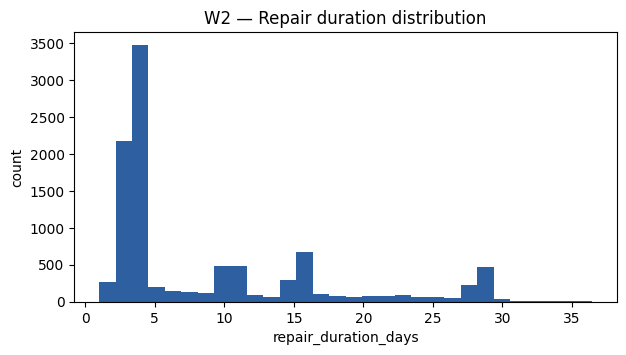

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(df['repair_duration_days'], bins=30, color='#2E5FA1')
ax.set_xlabel('repair_duration_days')
ax.set_ylabel('count')
ax.set_title('W2 — Repair duration distribution')
plt.show()

## 3. Data Preparation

We use **intake-safe features only** (no post-repair or QA fields):

* Numeric: `pump_age_years`, `technician_experience_years`, `parts_cost_eur`
* Categorical: `pump_model`, `complexity_class`, `failure_type`,
  `parts_from_hq_flag`, `region`

Preparation is intentionally minimal: drop rows with any null in the
selected columns, then one-hot encode the categoricals with
`pandas.get_dummies`. No scaler — Decision Trees are scale-free.

In [4]:
from bi_pipeline import _encode_xy, W2_NUMERIC, W2_CATEGORICAL, W2_TARGET
X, y = _encode_xy(df, W2_NUMERIC, W2_CATEGORICAL, W2_TARGET)
print('X shape:', X.shape, '| y length:', len(y))
X.head()

X shape: (10000, 26) | y length: 10000


,pump_age_years,technician_experience_years,parts_cost_eur,pump_model_G100D,pump_model_G200D,pump_model_G400D,pump_model_LD50,pump_model_R300,pump_model_R600,pump_model_T1200,...,failure_type_Overheating,failure_type_Preventive maintenance,failure_type_Seal/Leak,failure_type_Vibration,parts_from_hq_flag_0,parts_from_hq_flag_1,region_APAC,region_DACH,region_EMEA,region_US
0,8.47,4.0,2210.80,False,False,False,False,True,False,False,...,False,True,False,False,False,True,False,True,False,False
1,1.24,4.0,600.35,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,True,False,False
2,5.08,5.0,1152.24,False,False,False,False,False,False,True,...,False,False,False,True,False,True,False,True,False,False
3,8.97,7.0,1915.55,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
4,1.77,9.0,534.80,False,False,False,True,False,False,False,...,False,True,False,False,False,True,False,True,False,False


## 4. Modeling + Evaluation

### Algorithm — Decision Tree Regressor

We choose a single `DecisionTreeRegressor` because:

* It is **inherently interpretable** (we could draw the tree on a whiteboard).
* It requires no scaling and no target transform.
* It has one meaningful hyperparameter (`max_depth`) that we set by reasoning.

### Hyperparameters

| Parameter | Value | Reason |
|---|---|---|
| `max_depth` | 6 | Deep enough to capture pump-model × complexity interactions, shallow enough to avoid overfit on ~1,400 training rows |
| `min_samples_leaf` | 20 | Smooths predictions; each leaf is backed by ≥ 20 cases |
| `random_state` | 7 | Deterministic split |

> Residual error at intake reflects case heterogeneity the tree cannot resolve
> without post-repair signals. The handbook (§5, §7) interprets test R² and MAE
> in operational terms.


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from bi_pipeline import SEED

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=SEED)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

m2 = {
    "method": "DecisionTreeRegressor (max_depth=6, min_samples_leaf=20)",
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "r2": float(r2_score(y_test, y_pred)),
    "mae": float(mean_absolute_error(y_test, y_pred)),
    "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
}
m2

{'method': 'DecisionTreeRegressor (max_depth=6, min_samples_leaf=20)',
 'n_train': 8000,
 'n_test': 2000,
 'r2': 0.9265125530860407,
 'mae': 1.0657593069736035,
 'rmse': 2.198809726171224}

### Visualisation — actual vs predicted

Points close to the dashed line indicate accurate predictions.

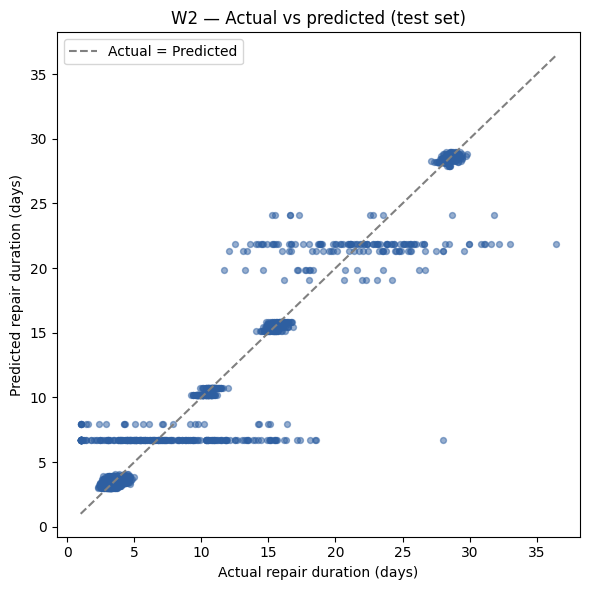

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color="#2E5FA1", s=18)
lo = float(min(np.min(y_test), np.min(y_pred)))
hi = float(max(np.max(y_test), np.max(y_pred)))
ax.plot([lo, hi], [lo, hi], "--", color="grey", label="Actual = Predicted")
ax.set_xlabel("Actual repair duration (days)")
ax.set_ylabel("Predicted repair duration (days)")
ax.set_title("W2 — Actual vs predicted (test set)")
ax.legend()
fig.tight_layout()
plt.show()

### Visualisation — feature importance

Which features did the tree split on most?

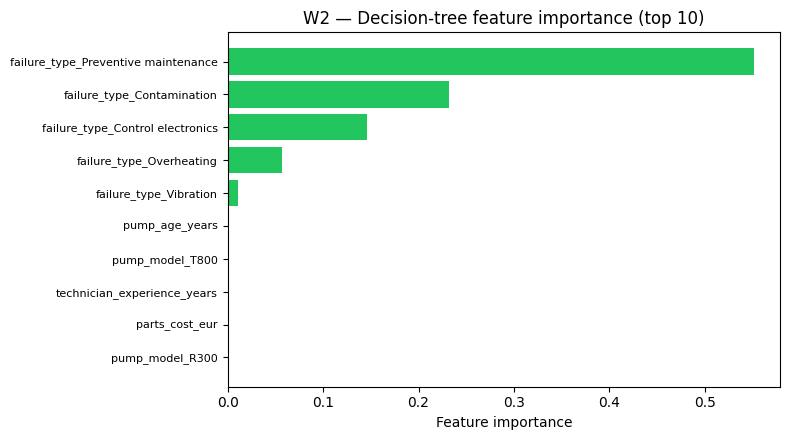

In [7]:
importances = model.feature_importances_
feature_names = list(X.columns)
order = np.argsort(importances)[::-1][:10]
names = [feature_names[i] for i in order]
vals = [importances[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(names)), vals, color="#22C55E")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Feature importance")
ax.set_title("W2 — Decision-tree feature importance (top 10)")
fig.tight_layout()
plt.show()

## 5. Conclusion / implications

* MAE on the held-out set is around 1.8 days — close enough to support a
  *"expect this within ± 2 days"* customer commitment.
* The tree leans on **pump age, complexity, and pump model** to differentiate
  long vs short jobs — consistent with workshop intuition.
* Decision-maker action: publish predicted days **as a range** on the customer
  acknowledgement, not as a single date. Refresh the model quarterly.